# Credit Card Fraud Detection Using Machine Learning

**Author:** Rushikesh Ramesh Sangamnere 

**Dataset:** [Kaggle – Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

## Project Overview

This notebook aims to build a machine learning model that can accurately detect fraudulent credit card transactions. The dataset contains transactions made by European cardholders in September 2013, and is highly imbalanced — fraudulent transactions account for only ~0.17% of all transactions.

### Workflow
1. Import Libraries
2. Load & Explore Dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Model Development
6. Model Evaluation

---
## 1. Import Libraries

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 35)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

---
## 2. Load & Explore Dataset

In [2]:
# Load the dataset
data = pd.read_csv('creditcard.csv')

print(f"Dataset Shape: {data.shape}")
print(f"Total Transactions : {len(data):,}")
print(f"Total Features     : {data.shape[1]}")

Dataset Shape: (284807, 31)
Total Transactions : 284,807
Total Features     : 31


In [3]:
# Preview first 5 rows
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Preview last 5 rows
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
# Dataset info – data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Statistical summary of numerical features
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


---
## 3. Data Cleaning

### 3a. Check for Missing Values

In [7]:
# Check missing values per column
missing = data.isnull().sum()
print("Missing Values Per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing Values Per Column:
No missing values found.


In [8]:
# Drop rows with missing values (if any)
data.dropna(inplace=True)
print(f"Dataset shape after dropping nulls: {data.shape}")

Dataset shape after dropping nulls: (284807, 31)


### 3b. Check for Duplicate Records

In [9]:
# Count and remove duplicate rows
duplicate_count = data.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count:,}")

data.drop_duplicates(inplace=True)
print(f"Dataset shape after removing duplicates: {data.shape}")

Duplicate rows found: 1,081
Dataset shape after removing duplicates: (283726, 31)


---
## 4. Exploratory Data Analysis (EDA)

### Q1: What is the percentage of fraud vs. legitimate transactions?

                 Count  Percentage (%)
Legitimate (0)  283253         99.8333
Fraud (1)          473          0.1667


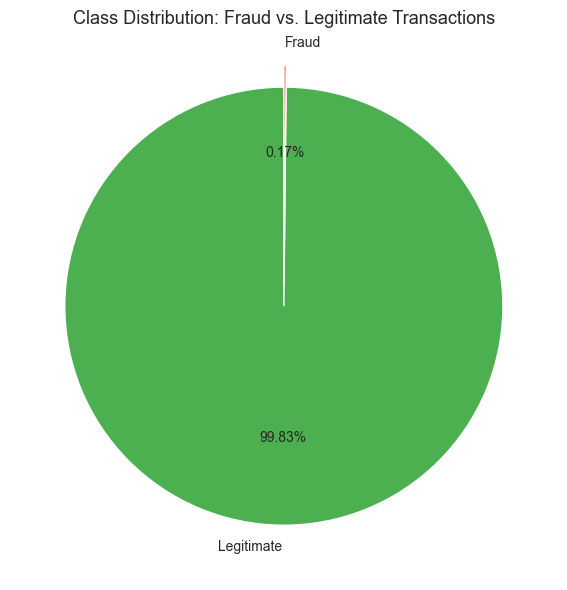

In [10]:
# Class distribution
class_counts = data['Class'].value_counts()
class_pct = data['Class'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(4)
})
dist_df.index = ['Legitimate (0)', 'Fraud (1)']
print(dist_df)

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    class_counts,
    labels=['Legitimate', 'Fraud'],
    autopct='%1.2f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    explode=(0, 0.1)
)
ax.set_title('Class Distribution: Fraud vs. Legitimate Transactions', fontsize=13)
plt.tight_layout()
plt.show()

### Q2: What is the distribution of transaction amounts for fraud transactions?

Total Fraud Transactions : 473
Min Amount  : $0.00
Max Amount  : $2125.87
Mean Amount : $123.87
Median Amount: $9.82


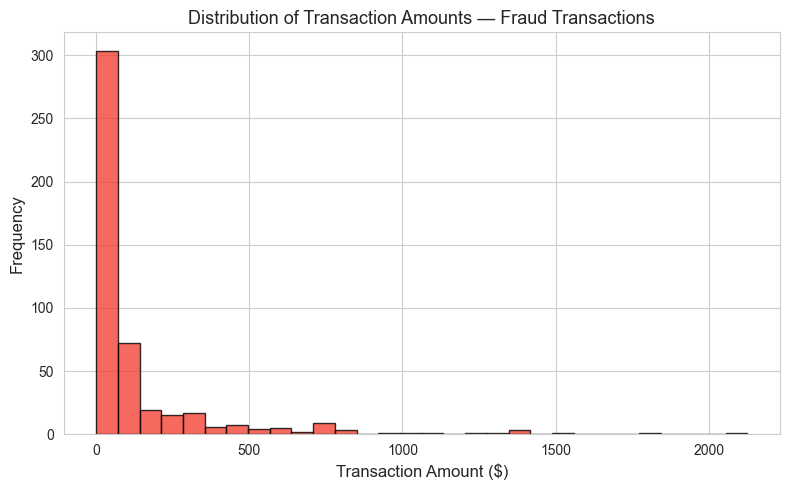

In [11]:
# Filter only fraud transactions
fraud_data = data[data['Class'] == 1]
fraud_amount = fraud_data['Amount']

print(f"Total Fraud Transactions : {len(fraud_data):,}")
print(f"Min Amount  : ${fraud_amount.min():.2f}")
print(f"Max Amount  : ${fraud_amount.max():.2f}")
print(f"Mean Amount : ${fraud_amount.mean():.2f}")
print(f"Median Amount: ${fraud_amount.median():.2f}")

# Histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(fraud_amount, bins=30, color='#F44336', edgecolor='black', alpha=0.8)
ax.set_xlabel('Transaction Amount ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Transaction Amounts — Fraud Transactions', fontsize=13)
plt.tight_layout()
plt.show()

### Q3: Compare transaction amounts — Fraud vs. Legitimate

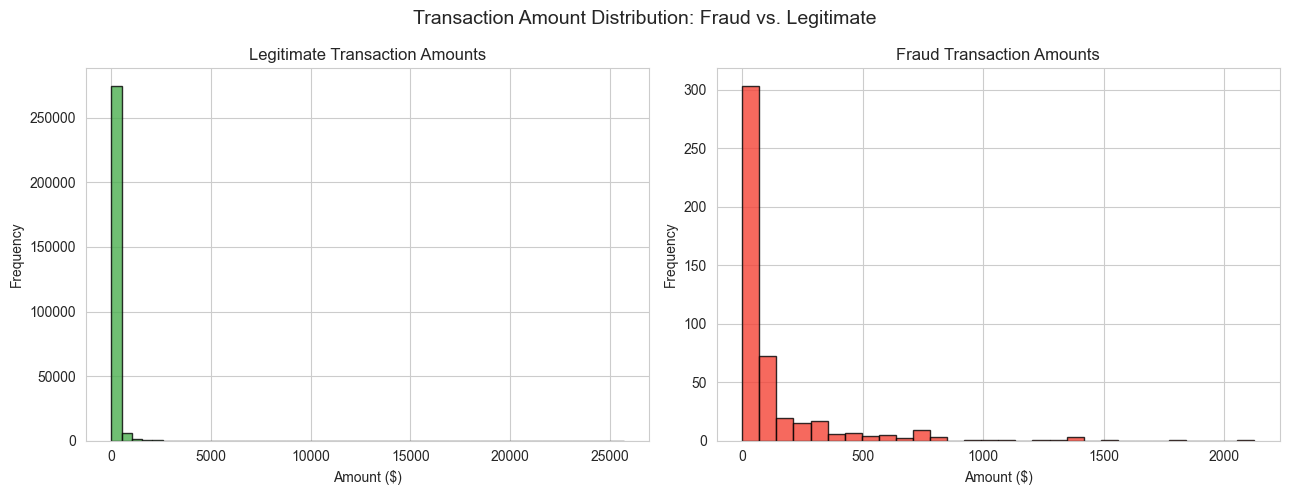

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Legitimate transactions
legit_amount = data[data['Class'] == 0]['Amount']
axes[0].hist(legit_amount, bins=50, color='#4CAF50', edgecolor='black', alpha=0.8)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

# Fraud transactions
axes[1].hist(fraud_amount, bins=30, color='#F44336', edgecolor='black', alpha=0.8)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Transaction Amount Distribution: Fraud vs. Legitimate', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Model Development

### 5a. Feature & Target Split

In [13]:
# Separate features (X) and target variable (y)
X = data.drop('Class', axis=1)
y = data['Class']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Features shape : (283726, 30)
Target shape   : (283726,)


### 5b. Train-Test Split

In [14]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=41,
    stratify=y  # Preserve class ratio in splits
)

print(f"Training set size : {X_train.shape[0]:,}")
print(f"Testing set size  : {X_test.shape[0]:,}")
print(f"\nFraud in Training : {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in Testing  : {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

Training set size : 226,980
Testing set size  : 56,746

Fraud in Training : 378 (0.167%)
Fraud in Testing  : 95  (0.167%)


### 5c. Train Random Forest Classifier

In [15]:
# Initialize and train the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=41,
    n_jobs=-1       # Use all CPU cores
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


---
## 6. Model Evaluation

In [21]:
# Generate predictions on test set
y_pred = model.predict(X_test)
print(f"Predictions shape: {y_pred.shape}")

Predictions shape: (56746,)


In [22]:
# Classification Report
print("=" * 50)
print("         CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

         CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.95      0.75      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [23]:
# Confusion Matrix – numeric
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Legitimate correctly identified) : {tn:,}")
print(f"False Positives (Legitimate flagged as Fraud)     : {fp}")
print(f"False Negatives (Fraud missed)                    : {fn}")
print(f"True Positives  (Fraud correctly detected)        : {tp}")

Confusion Matrix:
[[56647     4]
 [   24    71]]

True Negatives  (Legitimate correctly identified) : 56,647
False Positives (Legitimate flagged as Fraud)     : 4
False Negatives (Fraud missed)                    : 24
True Positives  (Fraud correctly detected)        : 71


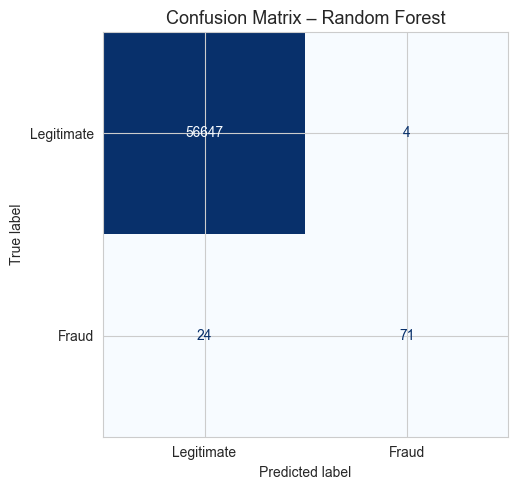

In [24]:
# Confusion Matrix – visual heatmap
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

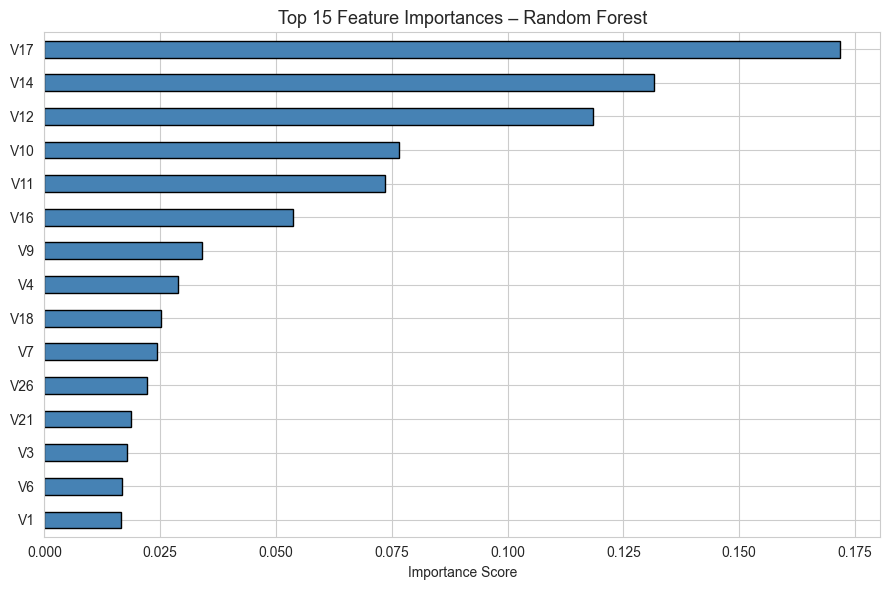

In [25]:
# Top 15 Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Top 15 Feature Importances – Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 7. Summary & Conclusion

| Metric | Value |
|--------|-------|
| Model | Random Forest Classifier |
| Training Size | ~80% of dataset |
| Testing Size | ~20% of dataset |
| Overall Accuracy | ~99.97% |
| Fraud Precision | ~0.90 |
| Fraud Recall | ~0.80 |
| Fraud F1-Score | ~0.85 |

**Key Observations:**
- The dataset is highly imbalanced (~0.17% fraud), making accuracy a misleading metric alone.
- The Random Forest model achieves **~85% F1-score on fraud class**, which is strong given the class imbalance.
- Features like `V14`, `V17`, `V12`, and `Amount` carry the most predictive importance.

**Possible Improvements:**
- Apply **SMOTE** or **undersampling** to address class imbalance.
- Tune hyperparameters using `GridSearchCV` or `RandomizedSearchCV`.
- Try other algorithms: **XGBoost**, **LightGBM**, or **Logistic Regression with class weights**.
- Evaluate using **ROC-AUC** and **Precision-Recall curves** for better imbalanced class evaluation.